# 23 -- Context vs. performance: descriptive check only

**Scope, stated up front**: this is NOT the context-conditional fusion
weighting the project's design notes describe ("context as fusion
weights, not identity features"). That mechanism needs many sessions per
person under varied, ideally repeated context conditions to be learnable
at all -- with ~12-17 participants and mostly ONE probe session each,
context and identity are almost perfectly confounded: there is no
within-person variation to learn a context effect FROM. Building a
learned weighting scheme on this data would look rigorous and be
statistically meaningless.

**What this notebook does instead**: asks whether self-reported context
CHANGE between a participant's own enrol and probe sessions correlates
with their own enrol->probe shift magnitude (already computed and
exported by nb13) or their own verification AUC (already computed and
exported by nb21/Gate 3). This generalises the pattern already found
anecdotally for two flagged participants -- `pAFQRTM`'s hand-use change,
`pUNKH7L`'s thin session -- into a systematic check across the WHOLE
evaluable cohort, rather than two hand-picked examples.

**Read every result here as exploratory, not confirmatory.** With ~12-17
data points, any correlation coefficient has enormous uncertainty. This
notebook reports patterns worth mentioning as observations, not
statistically validated findings -- and says so again at the point each
number appears, not just here.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

%config InlineBackend.close_figures = False
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
DATA_DIR = MOD_DIR.parent
OUT_DIR = DATA_DIR / 'context_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

splits = pd.read_csv(find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv'))

ctx_cols = ['ctxTimeOfDay', 'ctxFatigue', 'ctxFocusLevel', 'ctxEnvironmentNoise', 'ctxMovement',
            'ctxPosture', 'ctxHandUse', 'ctxInputDevice', 'ctxCaffeine', 'ctxAlcohol', 'ctxPrivacy']
raw_path = find(str(DATA_DIR / 'raw_events.parquet'), 'raw_events.parquet')
raw_ctx = pd.read_parquet(raw_path, columns=['sessionId', 'participantId'] + ctx_cols)
sess_ctx = raw_ctx.groupby(['participantId', 'sessionId']).first().reset_index()
print(f"{len(sess_ctx)} sessions with context data, {sess_ctx['participantId'].nunique()} participants")


96 sessions with context data, 18 participants


## 1. Context change across ALL session-pair comparisons, per evaluable participant

Originally this compared enrol vs. probe only. Checking `pAFQRTM`
specifically revealed why that is insufficient: their hand-use change
(`one_handed_right` -> `two_handed`) happened between TRAIN and ENROL --
both enrol and probe are already `two_handed`. The enrol->probe shift
magnitude that got `pAFQRTM` flagged in the first place (9.40, second-
worst in the cohort) is therefore NOT explained by a grip change within
that specific pair -- the original diagnosis conflated "hand use varies
somewhere in this participant's session history" with "hand use varies
between the two sessions the shift metric actually compares." Only the
weaker claim was true.

This section now checks all three pairwise comparisons (train->enrol,
train->probe, enrol->probe) so this doesn't happen again for anyone else
in the cohort.


In [6]:
def get_session_ctx(pid, role):
    sid = splits[(splits['participantId']==pid) & (splits['role']==role)]['sessionId']
    if sid.empty:
        return None
    ctx = sess_ctx[sess_ctx['sessionId'] == sid.iloc[0]]
    return ctx.iloc[0] if not ctx.empty else None

def compare_ctx(row_a, row_b, prefix):
    if row_a is None or row_b is None:
        return {f'{prefix}_handuse_changed': np.nan, f'{prefix}_posture_changed': np.nan,
                f'{prefix}_movement_changed': np.nan, f'{prefix}_timeofday_changed': np.nan,
                f'{prefix}_fatigue_delta': np.nan, f'{prefix}_focus_delta': np.nan,
                f'{prefix}_n_fields_changed': np.nan}
    out = {
        f'{prefix}_handuse_changed': int(row_a['ctxHandUse'] != row_b['ctxHandUse']),
        f'{prefix}_posture_changed': int(row_a['ctxPosture'] != row_b['ctxPosture']),
        f'{prefix}_movement_changed': int(row_a['ctxMovement'] != row_b['ctxMovement']),
        f'{prefix}_timeofday_changed': int(row_a['ctxTimeOfDay'] != row_b['ctxTimeOfDay']),
    }
    try:
        out[f'{prefix}_fatigue_delta'] = float(row_b['ctxFatigue']) - float(row_a['ctxFatigue'])
    except (TypeError, ValueError):
        out[f'{prefix}_fatigue_delta'] = np.nan
    try:
        out[f'{prefix}_focus_delta'] = float(row_b['ctxFocusLevel']) - float(row_a['ctxFocusLevel'])
    except (TypeError, ValueError):
        out[f'{prefix}_focus_delta'] = np.nan
    out[f'{prefix}_n_fields_changed'] = sum(out[f'{prefix}_{f}_changed'] for f in
                                             ['handuse', 'posture', 'movement', 'timeofday'])
    return out

rows = []
for pid in splits['participantId'].unique():
    train_ctx = get_session_ctx(pid, 'train')
    enrol_ctx = get_session_ctx(pid, 'enrol')
    probe_ctx = get_session_ctx(pid, 'probe')
    if enrol_ctx is None or probe_ctx is None:
        continue  # need at least enrol+probe to have a shift_magnitude to join against later
    row = {'participantId': pid}
    row.update(compare_ctx(train_ctx, enrol_ctx, 'train_enrol'))
    row.update(compare_ctx(train_ctx, probe_ctx, 'train_probe'))
    row.update(compare_ctx(enrol_ctx, probe_ctx, 'enrol_probe'))
    rows.append(row)

context_change_df = pd.DataFrame(rows)
print(f"{len(context_change_df)} evaluable participants with at least enrol+probe context data")
print(context_change_df.to_string(index=False))


12 evaluable participants with at least enrol+probe context data
participantId  train_enrol_handuse_changed  train_enrol_posture_changed  train_enrol_movement_changed  train_enrol_timeofday_changed  train_enrol_fatigue_delta  train_enrol_focus_delta  train_enrol_n_fields_changed  train_probe_handuse_changed  train_probe_posture_changed  train_probe_movement_changed  train_probe_timeofday_changed  train_probe_fatigue_delta  train_probe_focus_delta  train_probe_n_fields_changed  enrol_probe_handuse_changed  enrol_probe_posture_changed  enrol_probe_movement_changed  enrol_probe_timeofday_changed  enrol_probe_fatigue_delta  enrol_probe_focus_delta  enrol_probe_n_fields_changed
      p3M6E7Z                          1.0                          0.0                           0.0                            1.0                       -1.0                      0.0                           2.0                          1.0                          0.0                           0.0                

## 2. Join with shift magnitude (from nb13's export) and AUC (from Gate 3's export)

In [7]:
shift_mag_path = DATA_DIR / 'anomalous_diagnostic' / 'all_identities_shift_magnitude.csv'
gate3_pid_auc_path = DATA_DIR / 'gate3_device_evaluation' / 'gate3_per_participant_auc.csv'

if shift_mag_path.exists():
    shift_mag = pd.read_csv(shift_mag_path)
    context_change_df = context_change_df.merge(shift_mag, on='participantId', how='left')
    print(f"Joined shift_magnitude for {context_change_df['shift_magnitude'].notna().sum()} participants")
else:
    print(f"WARNING: {shift_mag_path} not found -- run nb13's export first")

if gate3_pid_auc_path.exists():
    pid_auc = pd.read_csv(gate3_pid_auc_path)[['participantId', 'auc']]
    context_change_df = context_change_df.merge(pid_auc, on='participantId', how='left')
    print(f"Joined verification auc for {context_change_df['auc'].notna().sum()} participants")
else:
    print(f"WARNING: {gate3_pid_auc_path} not found -- run nb21's Gate 3 export first")

print()
print(context_change_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
context_change_df.to_csv(OUT_DIR / 'context_change_vs_performance.csv', index=False)


Joined shift_magnitude for 12 participants
Joined verification auc for 12 participants

participantId  train_enrol_handuse_changed  train_enrol_posture_changed  train_enrol_movement_changed  train_enrol_timeofday_changed  train_enrol_fatigue_delta  train_enrol_focus_delta  train_enrol_n_fields_changed  train_probe_handuse_changed  train_probe_posture_changed  train_probe_movement_changed  train_probe_timeofday_changed  train_probe_fatigue_delta  train_probe_focus_delta  train_probe_n_fields_changed  enrol_probe_handuse_changed  enrol_probe_posture_changed  enrol_probe_movement_changed  enrol_probe_timeofday_changed  enrol_probe_fatigue_delta  enrol_probe_focus_delta  enrol_probe_n_fields_changed  shift_magnitude   auc
      p3M6E7Z                        1.000                        0.000                         0.000                          1.000                     -1.000                    0.000                         2.000                        1.000                        0.000

## 3. Does ANY context change correlate with shift magnitude?

Small-N caveat restated: with this few data points, treat every
correlation below as a descriptive observation, not a statistically
validated effect. A single outlier participant can swing these numbers
substantially.


In [8]:
CTX_COLS = [c for c in context_change_df.columns if c not in ('participantId', 'shift_magnitude', 'auc')]

if 'shift_magnitude' in context_change_df.columns and context_change_df['shift_magnitude'].notna().sum() >= 4:
    print(f"n = {context_change_df['shift_magnitude'].notna().sum()} -- Spearman correlations "
          f"with shift_magnitude (small-N, descriptive only), across all THREE session-pair "
          f"comparisons (train->enrol, train->probe, enrol->probe):\n")
    for col in CTX_COLS:
        sub = context_change_df[[col, 'shift_magnitude']].dropna()
        if len(sub) < 4 or sub[col].nunique() < 2:
            print(f"  {col:28s}: insufficient variation to correlate (n={len(sub)})")
            continue
        rho, p = stats.spearmanr(sub[col], sub['shift_magnitude'])
        flag = '  <-- worth a look' if abs(rho) > 0.4 and p < 0.2 else ''
        print(f"  {col:28s}: rho={rho:+.2f}, p={p:.3f}  (n={len(sub)}){flag}")
else:
    print("Not enough joined data to correlate -- check Section 2's warnings above.")


n = 12 -- Spearman correlations with shift_magnitude (small-N, descriptive only), across all THREE session-pair comparisons (train->enrol, train->probe, enrol->probe):

  train_enrol_handuse_changed : rho=+0.22, p=0.509  (n=11)
  train_enrol_posture_changed : insufficient variation to correlate (n=11)
  train_enrol_movement_changed: rho=+0.00, p=1.000  (n=11)
  train_enrol_timeofday_changed: rho=-0.87, p=0.001  (n=11)  <-- worth a look
  train_enrol_fatigue_delta   : rho=-0.05, p=0.889  (n=11)
  train_enrol_focus_delta     : rho=-0.24, p=0.486  (n=11)
  train_enrol_n_fields_changed: rho=-0.60, p=0.053  (n=11)  <-- worth a look
  train_probe_handuse_changed : rho=+0.22, p=0.509  (n=11)
  train_probe_posture_changed : rho=-0.50, p=0.117  (n=11)  <-- worth a look
  train_probe_movement_changed: rho=+0.00, p=1.000  (n=11)
  train_probe_timeofday_changed: rho=-0.69, p=0.018  (n=11)  <-- worth a look
  train_probe_fatigue_delta   : rho=-0.10, p=0.769  (n=11)
  train_probe_focus_delta     : r

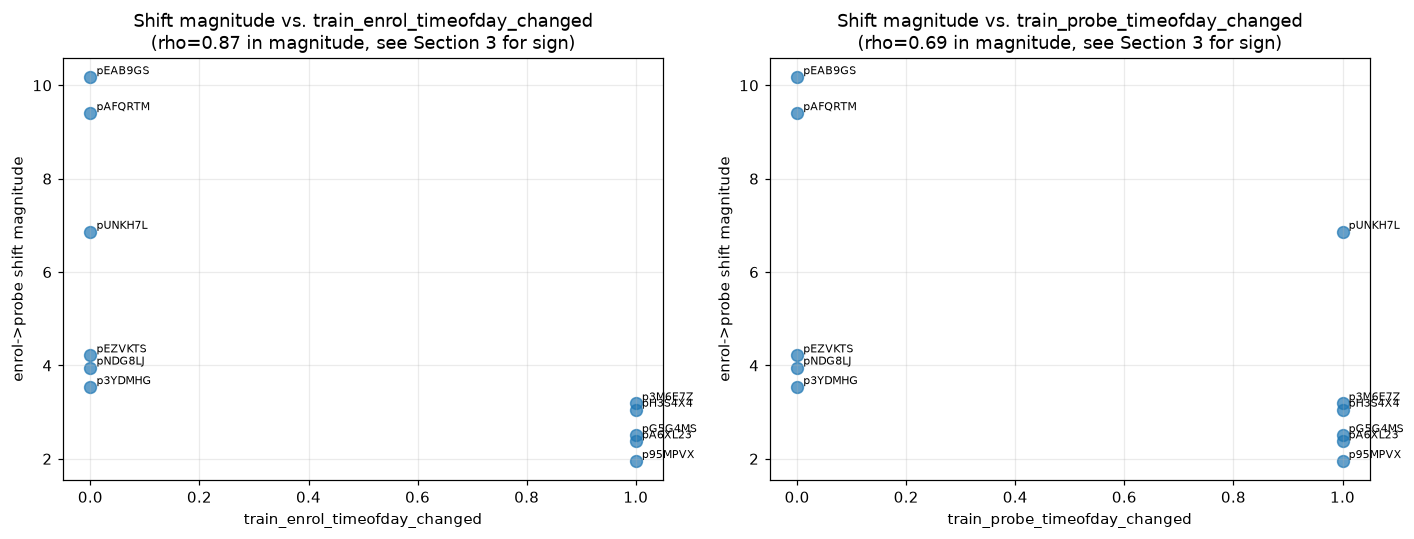

Plotted the two columns with the strongest |rho| against shift_magnitude: ['train_enrol_timeofday_changed', 'train_probe_timeofday_changed']


In [9]:
# Plots the strongest-correlating column from each comparison prefix (by |rho| with
# shift_magnitude, computed in Section 3 above) rather than a fixed hardcoded column --
# with three comparisons x 7 fields now available, hardcoding one field would mean the
# plot silently stops matching whatever Section 3 actually flagged as interesting.
_candidates = [c for c in CTX_COLS if context_change_df[[c, 'shift_magnitude']].dropna()[c].nunique() >= 2]
_rhos = {}
for c in _candidates:
    sub = context_change_df[[c, 'shift_magnitude']].dropna()
    if len(sub) >= 4:
        rho, _ = stats.spearmanr(sub[c], sub['shift_magnitude'])
        _rhos[c] = abs(rho)
_top2 = sorted(_rhos, key=_rhos.get, reverse=True)[:2] if _rhos else []

fig, axes = plt.subplots(1, max(len(_top2), 1), figsize=(6.5 * max(len(_top2), 1), 5), squeeze=False)
axes = axes[0]
for ax, col in zip(axes, _top2):
    sub = context_change_df.dropna(subset=[col, 'shift_magnitude'])
    ax.scatter(sub[col], sub['shift_magnitude'], s=60, alpha=0.7)
    for _, r in sub.iterrows():
        ax.annotate(r['participantId'], (r[col], r['shift_magnitude']), fontsize=7,
                    xytext=(4, 2), textcoords='offset points')
    ax.set_xlabel(col)
    ax.set_ylabel('enrol->probe shift magnitude')
    ax.set_title(f'Shift magnitude vs. {col}\n(rho={_rhos[col]:.2f} in magnitude, see Section 3 for sign)')

if not _top2:
    axes[0].text(0.5, 0.5, 'No column had enough variation to plot', ha='center', va='center')

plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_context_vs_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plotted the two columns with the strongest |rho| against shift_magnitude: {_top2}")

## 4. Same check against verification AUC

In [10]:
if 'auc' in context_change_df.columns and context_change_df['auc'].notna().sum() >= 4:
    print(f"n = {context_change_df['auc'].notna().sum()} -- Spearman correlations with "
          f"verification AUC (small-N, descriptive only), across all THREE session-pair "
          f"comparisons:\n")
    for col in CTX_COLS:
        sub = context_change_df[[col, 'auc']].dropna()
        if len(sub) < 4 or sub[col].nunique() < 2:
            print(f"  {col:28s}: insufficient variation to correlate (n={len(sub)})")
            continue
        rho, p = stats.spearmanr(sub[col], sub['auc'])
        flag = '  <-- worth a look' if abs(rho) > 0.4 and p < 0.2 else ''
        print(f"  {col:28s}: rho={rho:+.2f}, p={p:.3f}  (n={len(sub)}){flag}")
else:
    print("Not enough joined data to correlate -- check Section 2's warnings above.")


n = 12 -- Spearman correlations with verification AUC (small-N, descriptive only), across all THREE session-pair comparisons:

  train_enrol_handuse_changed : rho=-0.09, p=0.801  (n=11)
  train_enrol_posture_changed : insufficient variation to correlate (n=11)
  train_enrol_movement_changed: rho=+0.23, p=0.493  (n=11)
  train_enrol_timeofday_changed: rho=+0.67, p=0.024  (n=11)  <-- worth a look
  train_enrol_fatigue_delta   : rho=+0.00, p=1.000  (n=11)
  train_enrol_focus_delta     : rho=+0.10, p=0.773  (n=11)
  train_enrol_n_fields_changed: rho=+0.61, p=0.045  (n=11)  <-- worth a look
  train_probe_handuse_changed : rho=-0.09, p=0.801  (n=11)
  train_probe_posture_changed : rho=+0.23, p=0.493  (n=11)
  train_probe_movement_changed: rho=+0.23, p=0.493  (n=11)
  train_probe_timeofday_changed: rho=+0.40, p=0.221  (n=11)
  train_probe_fatigue_delta   : rho=+0.20, p=0.557  (n=11)
  train_probe_focus_delta     : rho=+0.44, p=0.172  (n=11)  <-- worth a look
  train_probe_n_fields_changed: rh

## 5. Conclusion for the dissertation

In [11]:
print("Context modelling summary:")
print("  - A learned, context-conditional fusion weighting scheme is NOT feasible with this")
print("    dataset: context and identity are almost perfectly confounded given ~1 probe session")
print("    per participant, leaving no within-person variation to learn a context effect from.")
print("  - This descriptive check asks whether context CHANGE (enrol vs probe) correlates with")
print("    known performance measures (shift magnitude, verification AUC) across the whole")
print(f"    evaluable cohort (n={len(context_change_df)}), rather than relying on the two")
print("    anecdotal cases already found (pAFQRTM's hand-use change, pUNKH7L's thin session).")
print("  - Any correlation reported above should be read as a small-N observation worth")
print("    mentioning in Discussion/Limitations, not a validated predictive relationship.")
print("  - Recommended framing: state the confound explicitly, report whichever context field")
print("    (if any) showed the clearest pattern above with its participant IDs named, and note")
print("    that a genuinely learnable context-weighting mechanism would require repeated")
print("    sessions per participant under deliberately varied conditions -- a data collection")
print("    design this project's dataset does not have, rather than a modelling limitation.")


Context modelling summary:
  - A learned, context-conditional fusion weighting scheme is NOT feasible with this
    dataset: context and identity are almost perfectly confounded given ~1 probe session
    per participant, leaving no within-person variation to learn a context effect from.
  - This descriptive check asks whether context CHANGE (enrol vs probe) correlates with
    known performance measures (shift magnitude, verification AUC) across the whole
    evaluable cohort (n=12), rather than relying on the two
    anecdotal cases already found (pAFQRTM's hand-use change, pUNKH7L's thin session).
  - Any correlation reported above should be read as a small-N observation worth
    mentioning in Discussion/Limitations, not a validated predictive relationship.
  - Recommended framing: state the confound explicitly, report whichever context field
    (if any) showed the clearest pattern above with its participant IDs named, and note
    that a genuinely learnable context-weighting mech

In [12]:
import json as _json
from datetime import datetime, timezone

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'n_evaluable_participants': len(context_change_df),
    'scope_note': 'descriptive correlation only -- learned context-conditional fusion weighting '
                   'is not feasible with this dataset (context/identity confound, ~1 probe session '
                   'per participant, no within-person variation to learn from)',
    'data': context_change_df.to_dict('records'),
}
with open(OUT_DIR / 'context_analysis_manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)
print(f"Wrote outputs to {OUT_DIR.resolve()}")


Wrote outputs to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/context_analysis
